In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('drive/MyDrive/Intent-Based Energy Reduction/Data/Floor3_features_selected.csv')

In [3]:
df.head()

,z1_AC2(kW),z1_AC3(kW),z1_Plug(kW),z1_S1(RH%),z1_S1(lux),z2_AC1(kW),z2_Light(kW),z2_Plug(kW),z2_S1(RH%),z2_S1(lux),...,z3_Plug(kW),z4_AC1(kW),z4_Light(kW),z4_Plug(kW),z4_S1(RH%),z4_S1(lux),z5_AC1(kW),z5_Light(kW),z5_Plug(kW),z5_S1(RH%)
0,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,...,0.26,0.0,0.0,0.02,65.66,0.0,0.0,0.0,0.02,71.16
1,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,...,0.37,0.0,0.0,0.02,65.65,0.0,0.0,0.0,0.02,71.16
2,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,...,0.32,0.0,0.0,0.02,65.63,0.0,0.0,0.0,0.02,71.18
3,0.0,0.0,0.03,60.66,0.0,0.0,0.0,0.03,63.36,0.0,...,0.26,0.0,0.0,0.02,0.00,0.0,0.0,0.0,0.02,71.19
4,0.0,0.0,0.03,60.66,0.0,0.0,0.0,0.03,63.36,0.0,...,0.37,0.0,0.0,0.02,0.00,0.0,0.0,0.0,0.02,71.21


In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, classification_report
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [5]:
features=list(df.columns)

In [6]:
features

['z1_AC2(kW)',
 'z1_AC3(kW)',
 'z1_Plug(kW)',
 'z1_S1(RH%)',
 'z1_S1(lux)',
 'z2_AC1(kW)',
 'z2_Light(kW)',
 'z2_Plug(kW)',
 'z2_S1(RH%)',
 'z2_S1(lux)',
 'z3_Light(kW)',
 'z3_Plug(kW)',
 'z4_AC1(kW)',
 'z4_Light(kW)',
 'z4_Plug(kW)',
 'z4_S1(RH%)',
 'z4_S1(lux)',
 'z5_AC1(kW)',
 'z5_Light(kW)',
 'z5_Plug(kW)',
 'z5_S1(RH%)']

In [7]:

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [8]:
model_iforest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
df['abnormal_iforest'] = model_iforest.fit_predict(df_scaled)

# Mark abnormals
df['abnormal_iforest'] = df['abnormal_iforest'].apply(lambda x: 1 if x == -1 else 0)


In [9]:
pca=PCA(n_components=2)
df_pca=pca.fit_transform(df_scaled)

In [10]:
df_pca[:,0]

array([-1.32668789, -1.20636499, -1.264352  , ..., -2.09935253,
       -2.09935253, -2.09338147])

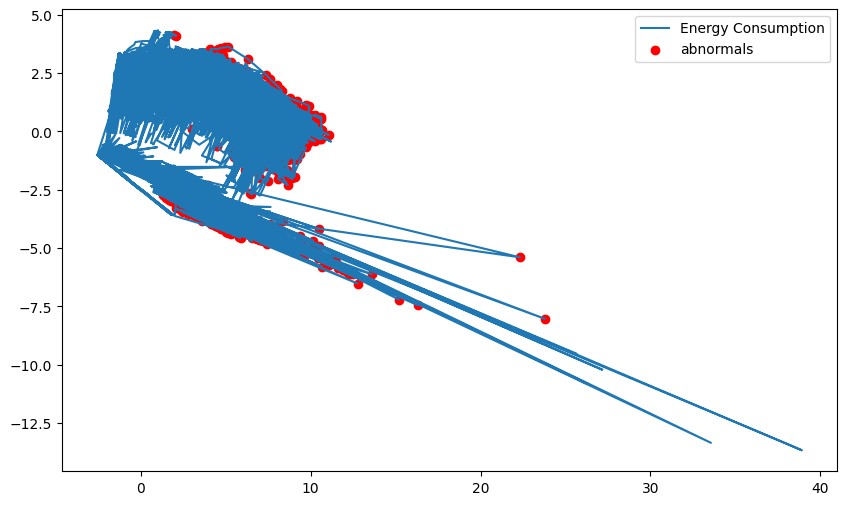

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(df_pca[:,0], df_pca[:,1], label='Energy Consumption')
plt.scatter(df_pca[:,0][df['abnormal_iforest'] == 1],df_pca[:,1][df['abnormal_iforest'] == 1], color='red', label='abnormals')
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


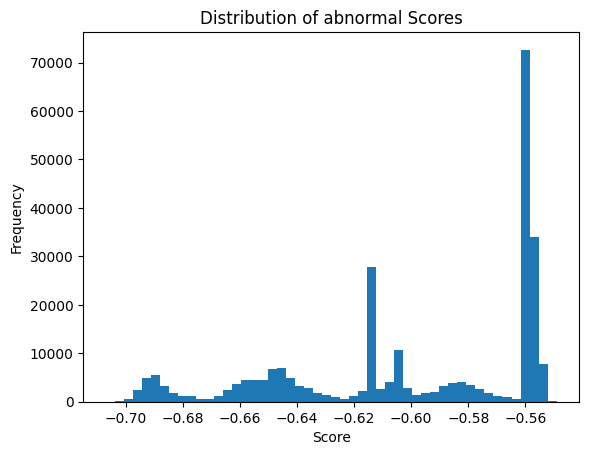

In [12]:
scores = model_iforest.score_samples(df[features])
plt.hist(scores, bins=50)
plt.title("Distribution of abnormal Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


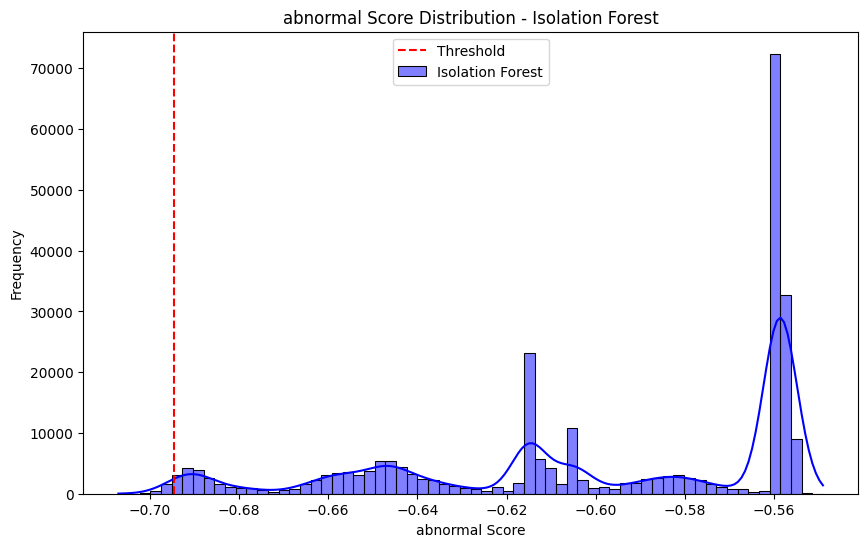

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(model_iforest.score_samples(df[features]), kde=True, color='blue', label='Isolation Forest')
plt.axvline(x=np.percentile(model_iforest.score_samples(df[features]), 1), color='red', linestyle='--', label='Threshold')
plt.title("abnormal Score Distribution - Isolation Forest")
plt.xlabel("abnormal Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [14]:
df['abnormal']=df['abnormal_iforest']

In [15]:
df.drop(['abnormal_iforest'],axis=1).to_csv('drive/MyDrive/Intent-Based Energy Reduction/Data/Floor3_abnormals_isolation_forest.csv',index=False)

In [16]:
from sklearn.pipeline import Pipeline

In [17]:
df=df[features]

In [18]:
df

,z1_AC2(kW),z1_AC3(kW),z1_Plug(kW),z1_S1(RH%),z1_S1(lux),z2_AC1(kW),z2_Light(kW),z2_Plug(kW),z2_S1(RH%),z2_S1(lux),...,z3_Plug(kW),z4_AC1(kW),z4_Light(kW),z4_Plug(kW),z4_S1(RH%),z4_S1(lux),z5_AC1(kW),z5_Light(kW),z5_Plug(kW),z5_S1(RH%)
0,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,...,0.26,0.0,0.0,0.02,65.66,0.0,0.0,0.0,0.02,71.16
1,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,...,0.37,0.0,0.0,0.02,65.65,0.0,0.0,0.0,0.02,71.16
2,0.0,0.0,0.03,60.67,0.0,0.0,0.0,0.03,63.37,0.0,...,0.32,0.0,0.0,0.02,65.63,0.0,0.0,0.0,0.02,71.18
3,0.0,0.0,0.03,60.66,0.0,0.0,0.0,0.03,63.36,0.0,...,0.26,0.0,0.0,0.02,0.00,0.0,0.0,0.0,0.02,71.19
4,0.0,0.0,0.03,60.66,0.0,0.0,0.0,0.03,63.36,0.0,...,0.37,0.0,0.0,0.02,0.00,0.0,0.0,0.0,0.02,71.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264955,0.0,0.0,0.03,0.00,0.0,0.0,0.0,0.02,0.00,0.0,...,0.37,0.0,0.0,0.01,0.00,0.0,0.0,0.0,0.02,0.00
264956,0.0,0.0,0.03,0.00,0.0,0.0,0.0,0.02,0.00,0.0,...,0.37,0.0,0.0,0.01,0.00,0.0,0.0,0.0,0.02,0.00
264957,0.0,0.0,0.03,0.00,0.0,0.0,0.0,0.02,0.00,0.0,...,0.37,0.0,0.0,0.01,0.00,0.0,0.0,0.0,0.02,0.00
264958,0.0,0.0,0.03,0.00,0.0,0.0,0.0,0.02,0.00,0.0,...,0.37,0.0,0.0,0.01,0.00,0.0,0.0,0.0,0.02,0.00


In [19]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', IsolationForest(n_estimators=100, contamination=0.01, random_state=42))
])

In [20]:
df['abnormal_pipeline'] = pipeline.fit_predict(df)

df['abnormal_pipeline'] = df['abnormal_pipeline'].apply(lambda x: 1 if x == -1 else 0)


In [21]:
pca=PCA(n_components=2)
df_pca=pca.fit_transform(df_scaled)

In [22]:
df_pca[:,0]

array([-1.32668789, -1.20636499, -1.264352  , ..., -2.09935253,
       -2.09935253, -2.09338147])

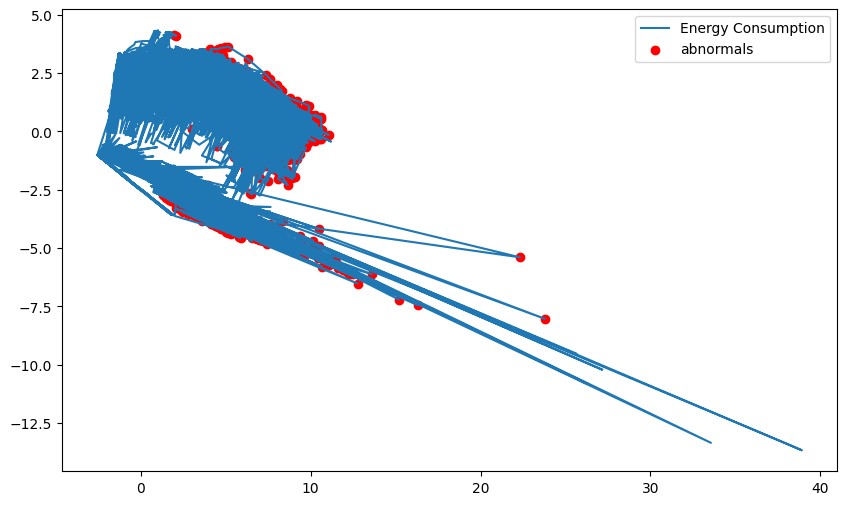

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(df_pca[:,0], df_pca[:,1], label='Energy Consumption')
plt.scatter(df_pca[:,0][df['abnormal_pipeline'] == 1],df_pca[:,1][df['abnormal_pipeline'] == 1], color='red', label='abnormals')
plt.legend()
plt.show()

In [24]:
import pickle

with open('drive/MyDrive/Intent-Based Energy Reduction/Abnormal Detection Model/model_iforest.pkl', 'wb') as f:
  pickle.dump(model_iforest, f)

with open('drive/MyDrive/Intent-Based Energy Reduction/Abnormal Detection Model/isolation_forest_pipeline.pkl', 'wb') as f:
  pickle.dump(pipeline, f)